<style>
h1, h2, h3 { color: #1f3a5f; }
</style>

# <span style="color:#1f3a5f;">Stage 3 · Flow Matching Before a Frozen Linear Classifier</span>

<p style="font-size:1.15em; color:#333333; margin:0.2em 0 0.8em 0;">
<b>DTD</b> with a frozen <b>ResNet-18</b> &nbsp;·&nbsp; <b>FGVC-Aircraft</b> with a frozen <b>DINOv2 ViT-S/14</b> &nbsp;·&nbsp; the Stage-1 linear classifier kept frozen
</p>

<div style="text-align:center; font-size:1.4em; line-height:2.4; margin:1.0em 0 1.0em 0;">
<span style="border:2px solid #1f3a5f; border-radius:6px; padding:4px 14px;">Image</span> →
<span style="border:2px solid #1f3a5f; border-radius:6px; padding:4px 14px;">Frozen Encoder</span> →
<b>z</b> →
<span style="background:#1f3a5f; color:#ffffff; border-radius:6px; padding:5px 16px; font-weight:bold;">Flow Matching</span> →
<b>ẑ</b> →
<span style="border:2px solid #1f3a5f; border-radius:6px; padding:4px 14px;">Frozen Linear Classifier</span> →
<span style="border:2px solid #1f3a5f; border-radius:6px; padding:4px 14px;">Prediction</span>
</div>

<p style="font-size:1.25em; margin-top:1.0em;"><b>Research question.</b> Can Flow Matching transform frozen encoder features into a representation that the existing frozen Stage-1 linear classifier separates better?</p>

In [1]:
# Shared setup: repository paths, configuration and display-name maps.
# Every later cell reads tables, training histories, figures and models of
# record under results/ — nothing is recomputed or written back.
import io
import json
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.utils import load_config
from src.visualize import class_palette, dataset_label, encoder_label

pd.set_option("display.precision", 2)
pd.set_option("display.max_rows", 200)

cfg = load_config()
MET = REPO / "results" / "metrics"
FIG = REPO / "results" / "figures"
CURVES = REPO / "results" / "artifacts" / "curves_stage3"
MODELS = REPO / "results" / "artifacts" / "stage3_models"
K_LABEL = f"{cfg['stage3']['k_shot']}shot"
S1_COLOR, S2_COLOR = "#0173B2", "#D55E00"      # Strategy 1 blue, Strategy 2 orange (as in the figures of record)


def show(fig, dpi=110):
    # Render a matplotlib figure as an embedded PNG (independent of the active backend).
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buf.getvalue()))

## <span style="color:#1f3a5f;">1 · Stage 3 setup</span>

- **The encoder remains frozen** — the features $z$ are extracted once and never change.
- **The Stage-1 linear classifier remains frozen** — retrained exactly as in Stage 1, then pinned; it is both the baseline and the classifier inside the pipeline.
- **Only the FM velocity network is trained.**
- **The FM starts as an exact identity transformation** — its final layer is zero-initialized, so at epoch 0 the complete pipeline behaves exactly like the pinned Stage-1 probe.

$$\hat{z}_{k+1} = \hat{z}_k + \frac{1}{T}\, v_\theta\!\left(\hat{z}_k,\ \frac{k}{T}\right), \qquad T = 4$$

Stage 3 operates in the **raw feature space** used by the linear classifier ($s = Wz + b$): no normalization is applied on entry, so the identity initialization is exact.

## <span style="color:#1f3a5f;">2 · Strategy 1 — rolled-out classification training</span>

1. Run the complete four-step FM rollout $z \to \hat{z}$.
2. Apply the frozen classifier to the transported feature $\hat{z}$.
3. Compute the cross-entropy against the true label.
4. Backpropagate through the whole rollout.
5. Update **only** the FM, with a relative displacement regularizer that discourages unnecessarily large moves.

$$\mathcal{L}_{\mathrm{S1}} = \mathrm{CE}(W\hat{z} + b,\ y) \;+\; \lambda\, \operatorname{mean}_i\, \frac{\lVert \hat{z}_i - z_i \rVert^2}{\lVert z_i \rVert^2 + \varepsilon}$$

Validation selected $\lambda = 1$ on both datasets (grid $\{0, 1, 10, 100\}$). The $\lambda = 0$ variant was also evaluated as a pre-registered pair; its complete table is in Appendix A.6.

## <span style="color:#1f3a5f;">3 · Strategy 2 — classifier-guided targets, standard FM training</span>

Each epoch contains two phases.

**Phase 1 — construct classifier-guided targets** (the frozen classifier is used here only):

$$u_0 = \Pi_{B(z,\rho)}(\hat{z}), \qquad \rho = 0.1\,\lVert z \rVert$$

$$u_{j+1} = \Pi_{B(z,\rho)}\!\left(u_j - \beta\rho\, \frac{\nabla_{u_j}\mathrm{CE}}{\lVert \nabla_{u_j}\mathrm{CE} \rVert + \varepsilon}\right), \qquad j = 0, \dots, m-1$$

- The current FM output $\hat{z}$ is projected into a trust region centred on the original feature $z$.
- Every candidate $u_j$ remains within the trust region.
- The candidate with the lowest CE is selected as the target $\hat{z}'$.
- The target is detached and cached for the epoch.

**Phase 2 — train the FM with standard velocity regression toward the cached targets:**

$$z_t = (1-t)\,z + t\,\hat{z}', \qquad t \sim U(0,1)$$

$$\mathcal{L}_{\mathrm{S2}} = \bigl\lVert\, v_\theta(z_t, t) - (\hat{z}' - z) \,\bigr\rVert^2$$

<div style="border-left:6px solid #0b7a75; background:#f2f8f7; color:#1a1a1a; padding:10px 16px; margin:0.8em 0; font-size:1.15em;">The classifier CE constructs the targets, but <b>no CE gradient reaches the FM</b>.</div>

## <span style="color:#1f3a5f;">4 · Strategy comparison</span>

| | Strategy 1 — rolled-out CE | Strategy 2 — classifier-guided targets |
|---|---|---|
| **Training signal** | cross-entropy backpropagated through the full rollout, plus a relative displacement penalty | standard velocity regression toward cached classifier-guided targets |
| **Role of the frozen classifier** | inside the loss — its gradient flows through the rollout into the FM | builds the targets — its gradient never reaches the FM |
| **How feature movement is constrained** | soft penalty on $\lVert\hat{z} - z\rVert^2 / \lVert z\rVert^2$ with weight $\lambda$ | hard trust region of radius $0.1\,\lVert z\rVert$ around $z$; lowest-CE candidate accepted |
| **Selected DTD configuration** | $\lambda = 1$ | $\beta = 0.25,\ m = 1$ |
| **Selected FGVC-Aircraft configuration** | $\lambda = 1$ | $\beta = 0.5,\ m = 3$ |

Both strategies train the same FM architecture with the same optimizer, epoch budget and checkpoint rule; only the training signal differs.

## <span style="color:#1f3a5f;">5 · Experimental protocol</span>

| | DTD | FGVC-Aircraft |
|---|---|---|
| **Frozen encoder** | ResNet-18 (ImageNet-1K), 512-dimensional features | DINOv2 ViT-S/14, 384-dimensional features |
| **Training set** | K = 10 examples per class; subset seeds 0, 1, 2 | K = 10 examples per class; subset seeds 0, 1, 2 |

- **T = 4** Euler steps; **exactly 200 training epochs**; the **best validation-accuracy checkpoint** is retained.
- Hyperparameters ($\lambda$; $\beta$, $m$) selected on **seed-0 validation** only, then applied unchanged to seeds 1 and 2.
- **Test data sealed** during training and model selection; evaluated once per locked checkpoint.
- **All validation guards passed:** exact identity at initialization; pinned probes reproduced the Stage-1 accuracies; no NaN or Inf failures (full audits in Appendix A.2–A.3).

## <span style="color:#1f3a5f;">6 · Main classification results</span>

Top-1 accuracy on the complete official test split; K = 10, T = 4; mean ± sample standard deviation over three subset seeds.

In [2]:
# Main comparison, generated from the summary of record (results/metrics/summary_stage3.csv)
# and cross-checked against the generated table of record (stage3_main_table.md, Appendix A.4).
summary = pd.read_csv(MET / "summary_stage3.csv")
record = (MET / "stage3_main_table.md").read_text(encoding="utf-8")
METHOD = {"pinned_probe": "Pinned Stage-1 probe", "fm_s1": "Strategy 1", "fm_s2": "Strategy 2"}
rows = []
for ds, enc in cfg["stage3"]["settings"]:
    for head in ("pinned_probe", "fm_s1", "fm_s2"):
        r = summary[(summary["dataset"] == ds) & (summary["encoder"] == enc)
                    & (summary["head"] == head)].iloc[0]
        acc = f"{100 * r['mean_acc']:.2f} ± {100 * r['std_acc']:.2f}"
        if head == "pinned_probe":
            delta = "baseline"
        else:
            delta = f"{100 * r['delta_mean']:+.2f} ± {100 * r['delta_std']:.2f}".replace("-", "−")
        # Every displayed value must appear verbatim in the table of record.
        assert acc in record and (delta == "baseline" or delta.replace("−", "-") in record), (acc, delta)
        rows.append({"Dataset": f"{dataset_label(ds)} / {encoder_label(enc, short=True)}",
                     "Method": METHOD[head], "Top-1 accuracy (%)": acc,
                     "Paired change (points)": delta})
main_table = pd.DataFrame(rows)


def _emphasize(row):
    best = row["Dataset"].startswith("FGVC") and row["Method"] == "Strategy 2"
    css = "font-size:1.2em; padding:8px 18px; white-space:nowrap;"
    return [css + (" font-weight:bold; background-color:#f2f8f7; color:#1a1a1a;" if best else "")] * len(row)


display(main_table.style.apply(_emphasize, axis=1).hide(axis="index")
        .set_table_styles([{"selector": "th", "props":
                            "font-size:1.2em; text-align:left; padding:8px 18px; color:#1f3a5f;"}]))

Dataset,Method,Top-1 accuracy (%),Paired change (points)
DTD / ResNet-18,Pinned Stage-1 probe,54.31 ± 0.28,baseline
DTD / ResNet-18,Strategy 1,53.62 ± 0.89,−0.69 ± 0.70
DTD / ResNet-18,Strategy 2,54.47 ± 0.70,+0.16 ± 0.45
FGVC-Aircraft / DINOv2,Pinned Stage-1 probe,51.30 ± 0.95,baseline
FGVC-Aircraft / DINOv2,Strategy 1,52.18 ± 1.11,+0.88 ± 0.23
FGVC-Aircraft / DINOv2,Strategy 2,53.80 ± 0.95,+2.50 ± 0.50


<div style="border-left:6px solid #0b7a75; background:#f2f8f7; color:#1a1a1a; padding:10px 16px; margin:0.8em 0; font-size:1.15em;"><b>Takeaway.</b> Strategy 2 improves FGVC-Aircraft on all three observed seeds, while DTD shows no clear benefit at this operating point.</div>

- Values are mean ± sample standard deviation over three subset seeds; each change is **paired per seed** against the exact pinned probe of that seed.
- Seed 0 was used for hyperparameter selection and is therefore partly a development run.
- "Consistent" describes agreement in sign across the three observed seeds; no statistical significance is claimed.
- Per-seed changes, the $\lambda = 0$ pair and the full validation sweep: Appendix A.5–A.7.

## <span style="color:#1f3a5f;">7 · Training behaviour — FGVC-Aircraft / DINOv2</span>

Validation-selected models, subset seed 0. Strategy 1 in blue, Strategy 2 in orange; dashed = training, solid = validation.

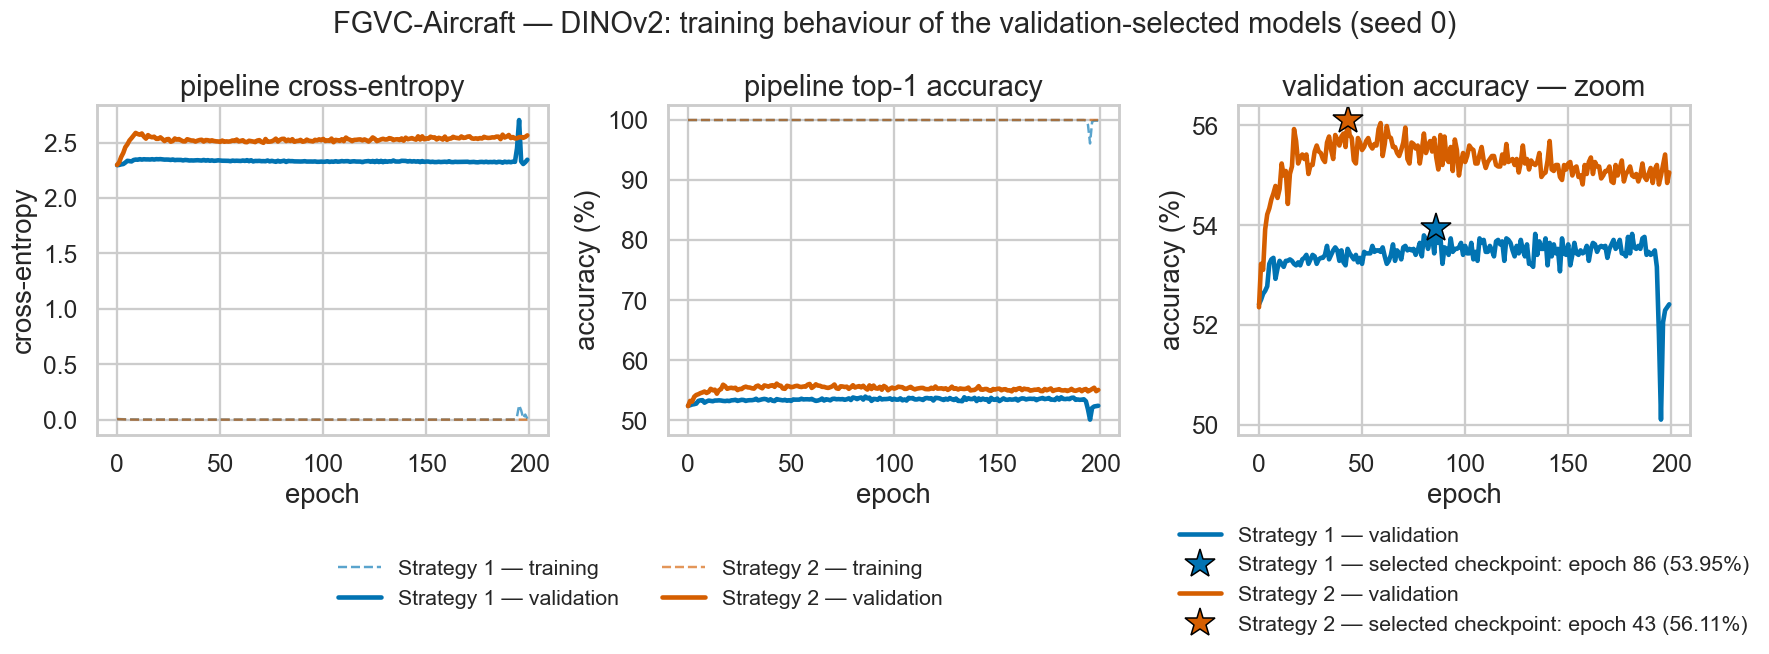

In [3]:
RUNS = pd.read_csv(MET / "runs_stage3.csv")


def _history(ds, enc, head, seed=0):
    with open(CURVES / f"{ds}_{enc}_{head}_seed{seed}.json") as f:
        return json.load(f)


def _checkpoint_epoch(ds, enc, head, seed=0):
    r = RUNS[(RUNS["dataset"] == ds) & (RUNS["encoder"] == enc)
             & (RUNS["head"] == head) & (RUNS["seed"] == seed)]
    return int(r["checkpoint_epoch"].iloc[0])


def training_figure(ds, enc, seed=0):
    # Training histories of record (results/artifacts/curves_stage3/*.json), the same
    # series as the figure of record stage3_curves_<ds>_<enc>.png (Appendix A.8),
    # drawn one dataset at a time with the validation-selected checkpoint of record
    # (runs_stage3.csv) marked.
    plt.rcParams.update({"font.size": 15, "axes.titlesize": 19, "axes.labelsize": 18,
                         "xtick.labelsize": 16, "ytick.labelsize": 16, "legend.fontsize": 14})
    fig, (ax_ce, ax_acc, ax_zoom) = plt.subplots(1, 3, figsize=(16.5, 6.0))
    for head, color, name in (("fm_s1", S1_COLOR, "Strategy 1"), ("fm_s2", S2_COLOR, "Strategy 2")):
        h, ep = _history(ds, enc, head, seed), _checkpoint_epoch(ds, enc, head, seed)
        assert h["epoch"][ep] == ep
        acc_train = [100 * v for v in h["train_pipeline_acc"]]
        acc_val = [100 * v for v in h["val_acc"]]
        ax_ce.plot(h["epoch"], h["train_pipeline_ce"], color=color, ls="--", lw=1.6, alpha=0.65,
                   label=f"{name} — training")
        ax_ce.plot(h["epoch"], h["val_ce"], color=color, lw=3.0, label=f"{name} — validation")
        ax_acc.plot(h["epoch"], acc_train, color=color, ls="--", lw=1.6, alpha=0.65,
                    label=f"{name} — training")
        ax_acc.plot(h["epoch"], acc_val, color=color, lw=3.0, label=f"{name} — validation")
        ax_zoom.plot(h["epoch"], acc_val, color=color, lw=3.0, label=f"{name} — validation")
        ax_zoom.plot([ep], [acc_val[ep]], ls="none", marker="*", ms=20, color=color, mec="black",
                     label=f"{name} — selected checkpoint: epoch {ep} ({acc_val[ep]:.2f}%)")
    ax_ce.set_title("pipeline cross-entropy")
    ax_ce.set_ylabel("cross-entropy")
    ax_acc.set_title("pipeline top-1 accuracy")
    ax_acc.set_ylabel("accuracy (%)")
    ax_zoom.set_title("validation accuracy — zoom")
    ax_zoom.set_ylabel("accuracy (%)")
    for ax in (ax_ce, ax_acc, ax_zoom):
        ax.set_xlabel("epoch")
    handles, labels = ax_acc.get_legend_handles_labels()
    ax_zoom.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=1, frameon=False)
    fig.tight_layout()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.36, ax_ce.get_position().y0 - 0.16))
    fig.suptitle(f"{dataset_label(ds)} — {encoder_label(enc, short=True)}: training behaviour of the "
                 f"validation-selected models (seed {seed})", fontsize=19, y=1.06)
    show(fig)


training_figure("fgvc_aircraft", "dinov2_vits14")

- Both strategies fit the training data almost completely (dashed lines: accuracy ≈ 100%, cross-entropy ≈ 0).
- Strategy 2 maintains higher validation accuracy through most of training (solid lines); ★ marks the validation-selected checkpoints.

## <span style="color:#1f3a5f;">8 · Training behaviour — DTD / ResNet-18</span>

Same layout and colours as the previous figure; validation-selected models, subset seed 0.

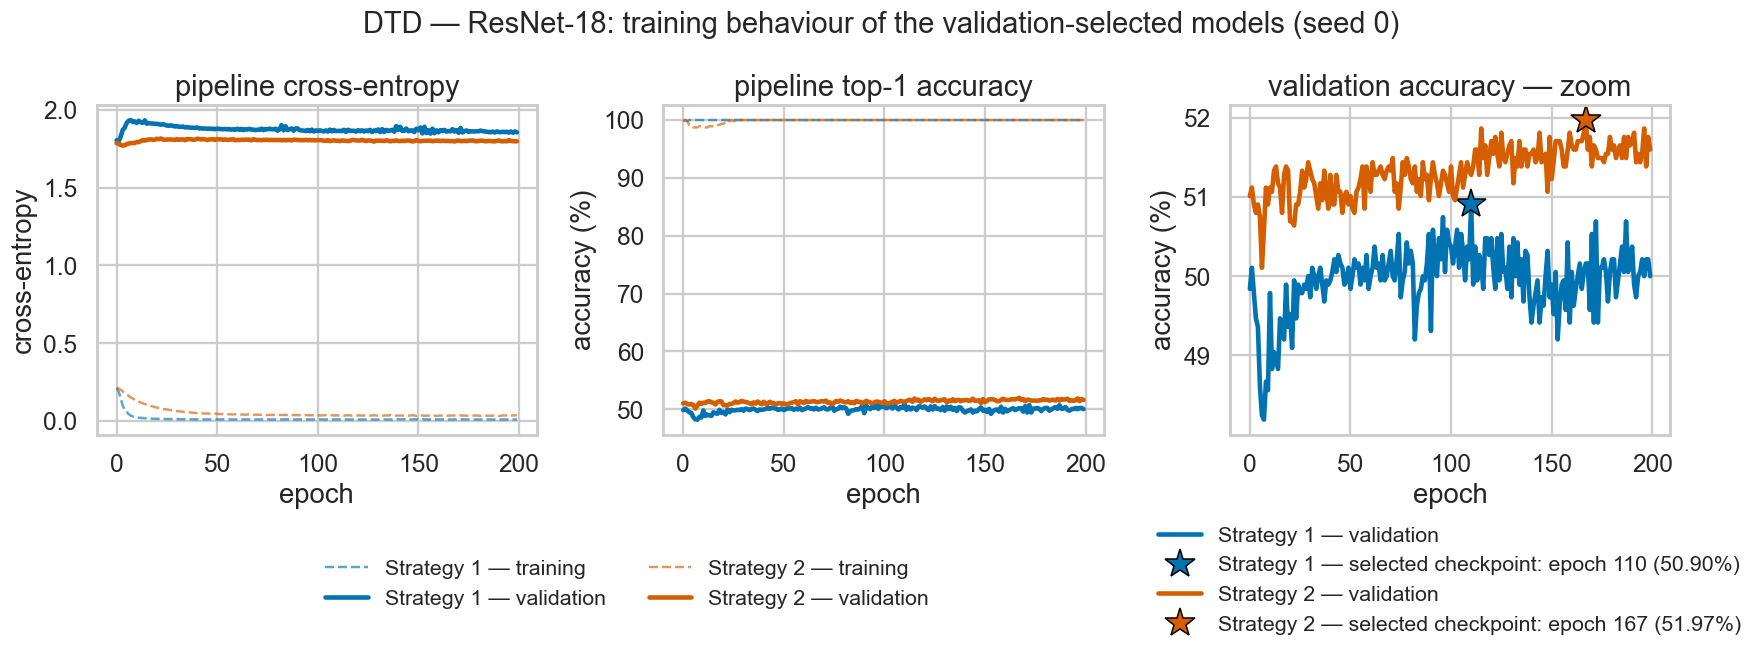

In [4]:
training_figure("dtd", "resnet18")

- Training accuracy approaches 100%, while validation remains near 50–52%.
- The validation curves remain close, matching the near-zero test change.

## <span style="color:#1f3a5f;">9 · Feature space — FGVC-Aircraft / DINOv2</span>

Ten classes of the shared visualization selection — the same test examples, classes and colours as in Stages 1–2. One PCA is fitted **jointly** over all three feature sets (original, after Strategy 1, after Strategy 2; seed-0 models), so the three panels share the same plane.

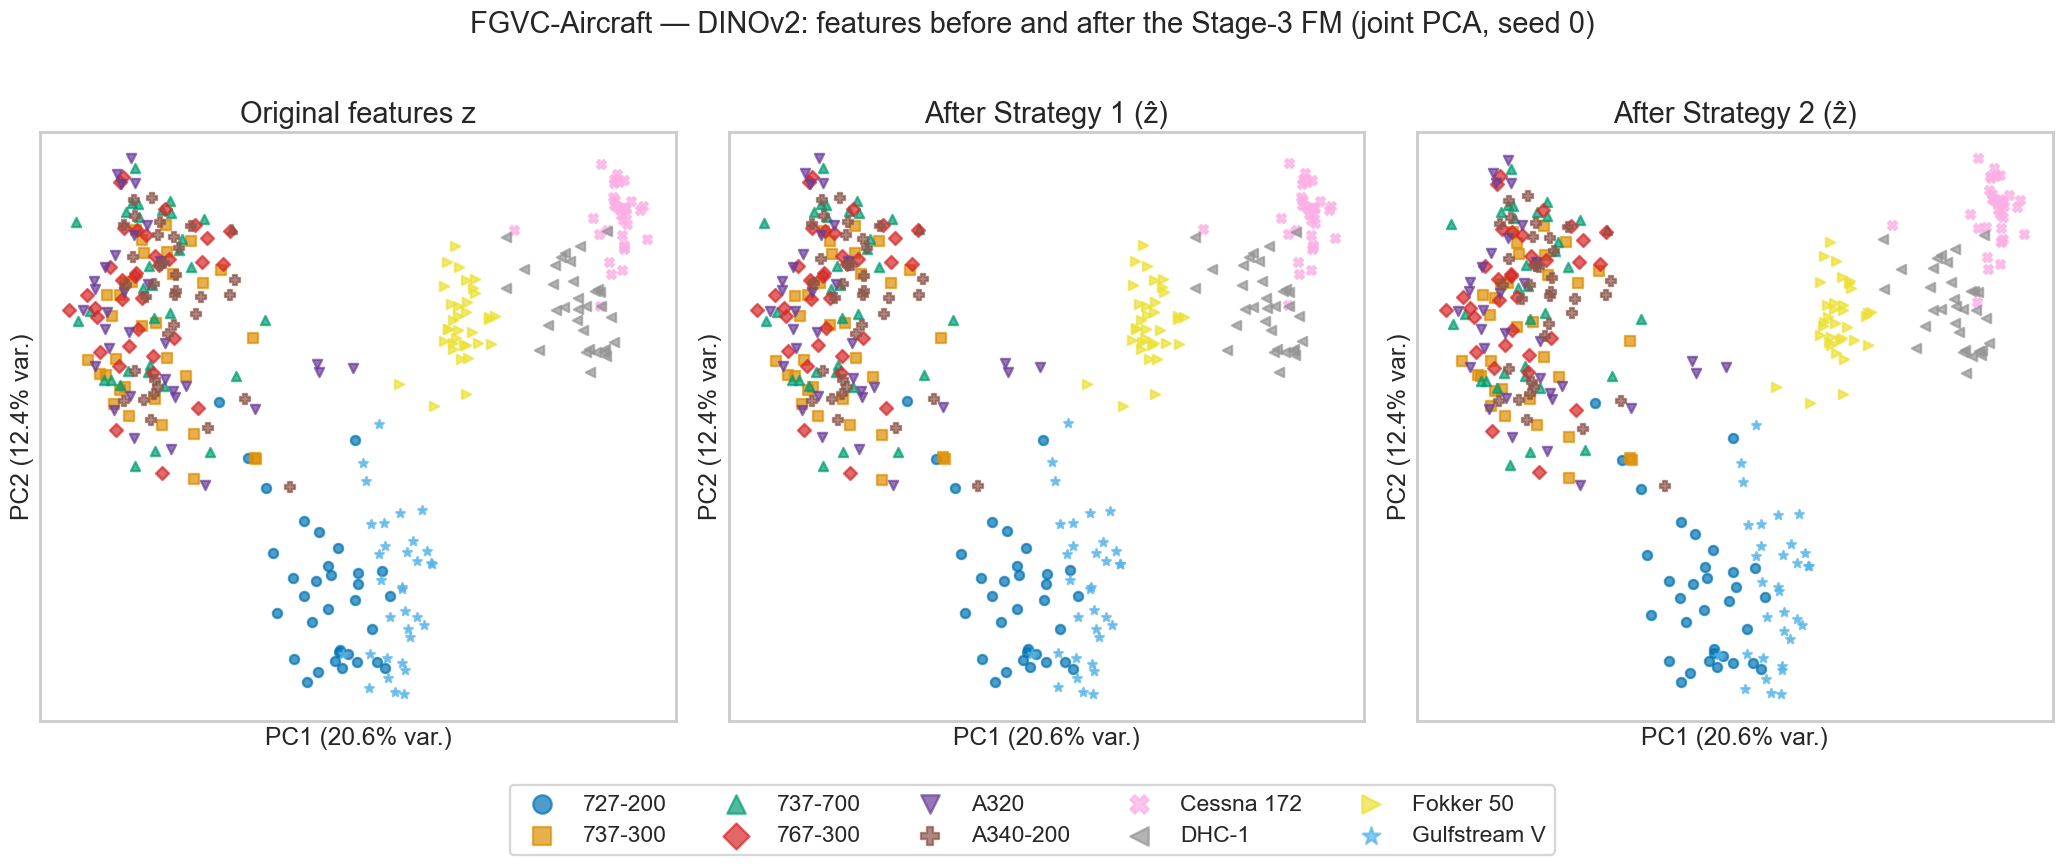

In [5]:
from make_figures import viz_selection
from make_figures_stage2 import _joint_pca, pc_labels
from src.embeddings import load_features
from src.stage3 import load_pinned_probe, load_stage3_fm

MARKERS = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "*"]


def feature_figure(ds, enc, expected_axes, seed=0):
    # Same selection, models and joint PCA as the figure of record
    # stage3_features_<ds>_<enc>.png (Appendix A.8); the explained-variance labels
    # are asserted to match that figure.
    vz = cfg["feature_viz"]
    classes, idx = viz_selection(ds, vz["n_classes"], vz["class_seed"], vz["max_per_class"])
    feats = load_features(ds, "test", enc)
    X = feats["features"][idx].float()                      # raw feature space
    remap = {int(c): j for j, c in enumerate(classes)}
    y = np.array([remap[int(v)] for v in feats["labels"][idx].numpy()])
    probe = load_pinned_probe(MODELS / f"probe_{ds}_{enc}_{K_LABEL}_seed{seed}.pt")
    Z1 = load_stage3_fm(MODELS / f"{ds}_{enc}_fm_s1_{K_LABEL}_seed{seed}.pt", probe).transport(X)
    Z2 = load_stage3_fm(MODELS / f"{ds}_{enc}_fm_s2_{K_LABEL}_seed{seed}.pt", probe).transport(X)
    pca, (xy0, xy1, xy2) = _joint_pca([X.numpy(), Z1.numpy(), Z2.numpy()])
    axes_labels = pc_labels(pca)
    assert axes_labels == expected_axes, axes_labels
    names = [feats["class_names"][c] for c in classes]
    palette = class_palette(len(names))

    fig, axes = plt.subplots(1, 3, figsize=(19, 6.8))
    panels = ((xy0, "Original features z"), (xy1, "After Strategy 1 (ẑ)"), (xy2, "After Strategy 2 (ẑ)"))
    for ax, (xy, title) in zip(axes, panels):
        for j, name in enumerate(names):
            m = y == j
            ax.scatter(xy[m, 0], xy[m, 1], s=36, alpha=0.7, color=palette[j],
                       marker=MARKERS[j % len(MARKERS)], label=name)
        ax.set_title(title, fontsize=19)
        ax.set_xlabel(axes_labels[0], fontsize=16)
        ax.set_ylabel(axes_labels[1], fontsize=16)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=5,
               fontsize=15, frameon=True, markerscale=2.0)
    fig.suptitle(f"{dataset_label(ds)} — {encoder_label(enc, short=True)}: features before and after "
                 f"the Stage-3 FM (joint PCA, seed {seed})", fontsize=19, y=1.02)
    fig.tight_layout()
    show(fig)


feature_figure("fgvc_aircraft", "dinov2_vits14", ("PC1 (20.6% var.)", "PC2 (12.4% var.)"))

- The first two components explain 33.0% of the variance.
- The visible movement is subtle despite the +2.50-point accuracy gain.
- Useful movement may occur along classifier-relevant directions outside the displayed plane; the projection does not establish the mechanism.

## <span style="color:#1f3a5f;">10 · Feature space — DTD / ResNet-18</span>

Same construction as the previous figure: the shared ten-class selection, one PCA fitted jointly over the three feature sets, seed-0 models.

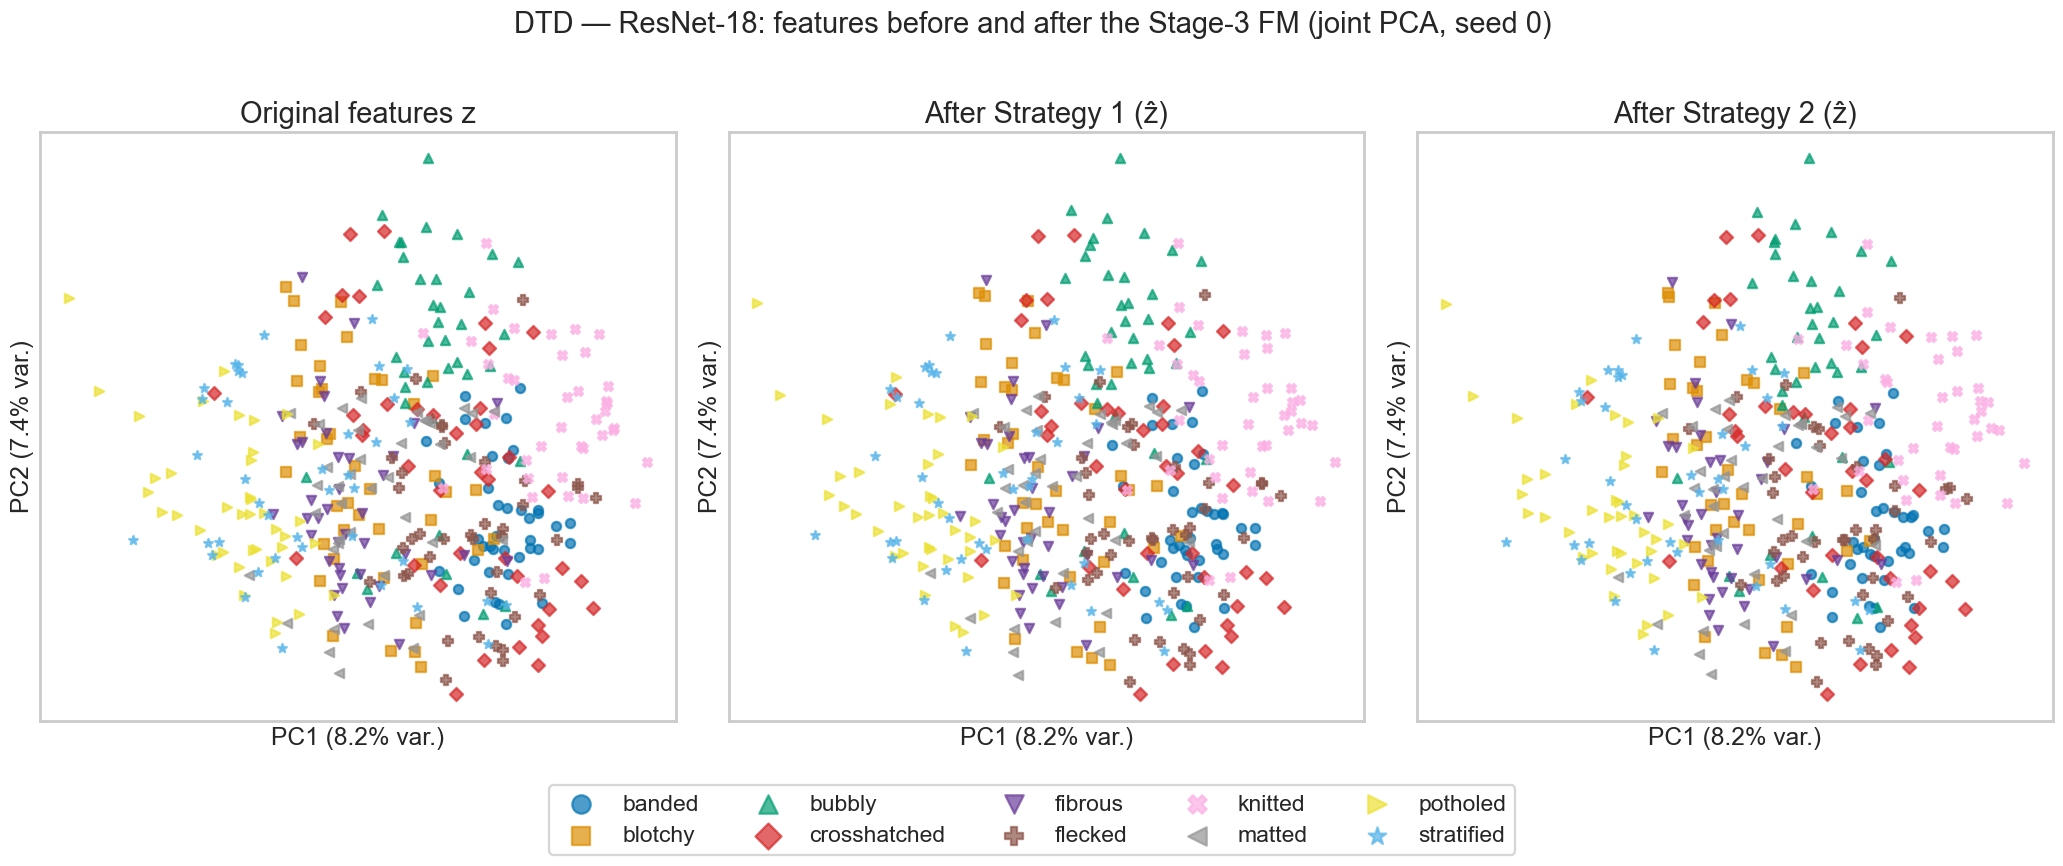

In [6]:
feature_figure("dtd", "resnet18", ("PC1 (8.2% var.)", "PC2 (7.4% var.)"))

- The first two components explain 15.6% of the variance.
- The projection changes little across the methods.
- This is consistent with the lack of a clear classification improvement.

Both PCA figures are qualitative two-dimensional views of transformations that take place in the full 384-dimensional (DINOv2) and 512-dimensional (ResNet-18) feature spaces.

## <span style="color:#1f3a5f;">11 · Conclusions</span>

1. **Strategy 2 is the best tested configuration on FGVC-Aircraft:** a paired gain of +2.50 ± 0.50 points, with positive changes on all three seeds.
2. **DTD shows no clear improvement** at the tested operating point.
3. **The indirect classifier-guided strategy outperforms direct rolled-out CE training on both datasets.**

**Caveat.** Strategy 2 changes several components simultaneously — target construction, trust-region projection, lowest-CE acceptance and standard path regression. The experiment therefore supports the complete strategy but does not identify which individual component causes the advantage.

## <span style="color:#1f3a5f;">12 · Limitations and final takeaway</span>

- Only three subset seeds.
- Seed 0 was used for hyperparameter selection.
- Only one K, one T and one encoder per dataset were tested.
- PCA is a qualitative two-dimensional projection.

<div style="border-left:6px solid #0b7a75; background:#f2f8f7; color:#1a1a1a; padding:12px 18px; margin:1.0em 0; font-size:1.2em;"><b>Takeaway.</b> Flow Matching before a frozen classifier is not universally beneficial, but conservative classifier-guided targets provide a consistent improvement on the fine-grained FGVC-Aircraft setting.</div>

# <span style="color:#1f3a5f;">Appendix — detailed evidence for questions</span>

Reference material moved out of the main flow. The complete scientific report remains `stage3_presentation.ipynb`.

- **A.1** complete environment and configuration, including the training and fallback policy
- **A.2** exact-identity audit (re-executed) · **A.3** pinned-probe reproduction audit
- **A.4** main table of record with its full caption · **A.5** full seed-0 validation sweep · **A.6** λ ablation · **A.7** per-seed paired deltas
- **A.8** figures of record and strategy-internal diagnostics · **A.9** checkpoint and displacement table
- **A.10** optional joint-training experiment · **A.11** classifier-only continued-training control
- **A.12** full limitations · **A.13** deviations from the specification · **A.14** artifact paths and reproduction commands

## <span style="color:#1f3a5f;">A.1 · Complete environment and configuration</span>

In [7]:
# Runtime provenance and the Stage-3 configuration block, as recorded in the repository.
with open(REPO / "results" / "runtime_summary.json") as f:
    print("Runtime:", json.dumps(json.load(f), indent=2))
s3 = cfg["stage3"]
print("\nSettings:", s3["settings"], "| K =", s3["k_shot"], "| T =", s3["T"],
      "| feature space:", s3["feature_space"])
print("Training policy:", json.dumps(s3["training"], indent=2))
print("Strategy 1 lambda grid:", s3["strategy1"]["lambda_grid"],
      "| Strategy 2 grid: beta", s3["strategy2"]["beta_grid"], "x m", s3["strategy2"]["m_grid"],
      "| trust-region alpha =", s3["strategy2"]["alpha_trust_region"])

Runtime: {
  "python": "3.12.3",
  "platform": "Windows-10-10.0.19045-SP0",
  "torch": "2.9.1+rocm7.2.1",
  "cuda_available": true,
  "device_name": "AMD Radeon RX 7900 XTX",
  "device": "cuda",
  "matmul_ok": true
}

Settings: [['dtd', 'resnet18'], ['fgvc_aircraft', 'dinov2_vits14']] | K = 10 | T = 4 | feature space: raw
Training policy: {
  "optimizer": "adamw",
  "lr": 0.001,
  "weight_decay": 0.0001,
  "batch_size": 64,
  "epochs": 200,
  "checkpoint_selection": "highest_validation_accuracy",
  "fallbacks": [
    "grad_clip_1.0",
    "lr_3e-4",
    "input_standardization"
  ]
}
Strategy 1 lambda grid: [0, 1, 10, 100] | Strategy 2 grid: beta [0.25, 0.5, 1.0] x m [1, 3] | trust-region alpha = 0.1


**Provenance of every choice.** The FM operates in **raw feature space** — the probe was trained on raw features ($s = Wz + b$, norms ≈ 10–40), so normalizing on entry would break the required identity-at-initialization (note the deliberate contrast with Stage 2, where the downstream classifier was cosine-based and the FM therefore lived on the unit sphere: *the FM operates in the space its downstream classifier acts in*). The velocity network and Euler procedure are the Stage-2 design, as the spec instructs (MLP $d{+}1 \to 512 \to 512 \to d$, SiLU, scalar $t$ concatenated; $\hat{z}_{k+1} = \hat{z}_k + \frac{1}{T}v_\theta(\hat{z}_k, k/T)$). **Identity initialization is exact**: the final velocity layer (weight *and* bias) starts at zero, so $\hat{z} = z$ bit-for-bit — asserted, not assumed (A.2).

**Training policy (uniform for both strategies, fixed a priori):** AdamW, lr $10^{-3}$, weight decay $10^{-4}$, batch 64, exactly 200 epochs with the **best-validation-accuracy checkpoint** retained (ties → lowest validation CE → earliest epoch). Validation-based selection is deliberate and symmetric: the baseline probe itself was selected the same way in Stage 1, and both strategies expose the identical full-pipeline validation curve. Failure policy (objective trigger — NaN/Inf loss only): restart with the next pre-registered fallback (cumulative ladder: grad-clip 1.0 → lr 3e-4 → internal input standardization, which preserves the exact identity); finite late deterioration is absorbed by checkpointing; exhausted ladder ⇒ run marked failed. **Hyperparameters were selected per dataset on seed-0 validation only**; winners applied unchanged to seeds 1–2; the **test split stayed sealed** during all training and selection, and was evaluated in **one final pass per pre-registered phase** (the mandatory grid; then the optional extension), each over its already-locked checkpoints. Disclosed: seed 0 is therefore partly a development run, and the 3-seed mean is a summary, not an independent confirmatory estimate.

## <span style="color:#1f3a5f;">A.2 · Exact-identity audit</span>

Transported features must be **bit-exact equal** to the inputs at initialization, with equal logits and identical predictions between the pipeline and the direct probe — stronger than accuracy equality (two systems can share accuracy while disagreeing on many predictions). Re-executed live below on validation data only.

In [8]:
import torch

from src.embeddings import load_features
from src.stage3 import Stage3FM, identity_guard, load_pinned_probe

print("Exact-identity guard (re-executed live, validation data only):")
for ds, enc in cfg["stage3"]["settings"]:
    probe = load_pinned_probe(MODELS / f"probe_{ds}_{enc}_{K_LABEL}_seed0.pt")
    fval = load_features(ds, "val", enc)
    fm0 = Stage3FM(probe, fval["dim"], seed=cfg["stage3"]["fm_init_seed"])
    identity_guard(fm0, fval["features"][:256])
    print(f"  [OK] {ds} / {enc}: transported features bit-exact, logits and "
          f"predictions identical to the direct probe")

Exact-identity guard (re-executed live, validation data only):
  [OK] dtd / resnet18: transported features bit-exact, logits and predictions identical to the direct probe
  [OK] fgvc_aircraft / dinov2_vits14: transported features bit-exact, logits and predictions identical to the direct probe


## <span style="color:#1f3a5f;">A.3 · Pinned-probe reproduction audit</span>

The probe is retrained with the identical Stage-1 recipe per (dataset, subset seed), its **validation** accuracy audited against `runs.csv` (|diff| < 0.25 pts; the run log shows 0.000 pts and identical best epochs on all six probes), and the weights pinned so every method receives the same frozen classifier. Δ is computed against **this exact pinned probe** — `runs.csv` serves as a reproduction audit only; the cell below displays the recorded accuracies reproducing the published values within $10^{-12}$ (test compared post-hoc at the final pass).

In [9]:
# Pinned probes' validation and test accuracies against the published Stage-1 values.
r1 = pd.read_csv(MET / "runs.csv")
r3 = pd.read_csv(MET / "runs_stage3.csv")
rows = []
for ds, enc in cfg["stage3"]["settings"]:
    for seed in cfg["stage3"]["subset_seeds"]:
        pin = r3[(r3["dataset"] == ds) & (r3["encoder"] == enc)
                 & (r3["head"] == "pinned_probe") & (r3["seed"] == seed)].iloc[0]
        ref = r1[(r1["dataset"] == ds) & (r1["encoder"] == enc)
                 & (r1["head"] == "linear_probe") & (r1["k_shot"] == K_LABEL)
                 & (r1["seed"] == seed)].iloc[0]
        rows.append({"dataset": ds, "seed": seed,
                     "pinned val (%)": round(100 * pin["val_acc"], 4),
                     "Stage-1 val (%)": round(100 * ref["val_acc"], 4),
                     "pinned test (%)": round(100 * pin["test_acc"], 4),
                     "Stage-1 test (%)": round(100 * ref["test_acc"], 4),
                     "within 1e-12": bool(np.isclose(pin["val_acc"], ref["val_acc"],
                                                     rtol=0, atol=1e-12)
                                          and np.isclose(pin["test_acc"],
                                                         ref["test_acc"],
                                                         rtol=0, atol=1e-12))})
audit = pd.DataFrame(rows)
assert audit["within 1e-12"].all()
print("Pinned-probe reproduction audit — recorded validation and test accuracies "
      "reproduce the published Stage-1 values within 1e-12 on all six probes "
      "(equal accuracies do not by themselves prove identical weights; the "
      "feature-level bit-exactness claim belongs to the identity guard above):")
display(audit)

Pinned-probe reproduction audit — recorded validation and test accuracies reproduce the published Stage-1 values within 1e-12 on all six probes (equal accuracies do not by themselves prove identical weights; the feature-level bit-exactness claim belongs to the identity guard above):


,dataset,seed,pinned val (%),Stage-1 val (%),pinned test (%),Stage-1 test (%),within 1e-12
0,dtd,0,50.74,50.74,53.99,53.99,True
1,dtd,1,54.10,54.10,54.47,54.47,True
2,dtd,2,51.33,51.33,54.47,54.47,True
3,fgvc_aircraft,0,52.51,52.51,52.12,52.12,True
4,fgvc_aircraft,1,51.43,51.43,51.52,51.52,True
5,fgvc_aircraft,2,49.35,49.35,50.26,50.26,True


## <span style="color:#1f3a5f;">A.4 · Main table of record (with its full caption)</span>

Every number is generated programmatically from `results/metrics/` and re-derived by the repro check; raw per-run accuracies in `results/metrics/raw/stage3_*.npy`, the per-run table in `runs_stage3.csv`. Δ is **paired per seed** against the exact pinned probe of that seed.

In [10]:
display(Markdown((MET / "stage3_main_table.md").read_text(encoding="utf-8")))

| Dataset / encoder | Head | Top-1 (%) | Δ vs pinned probe (pts, paired) |
|---|---|---|---|
| DTD / ResNet-18 | Pinned Stage-1 probe (baseline) | 54.31 ± 0.28 | — |
| DTD / ResNet-18 | Strategy 1 — rolled-out CE training (λ = 1) | 53.62 ± 0.89 | -0.69 ± 0.70 (1/3 seeds > 0) |
| DTD / ResNet-18 | Strategy 2 — classifier-guided targets (β = 0.25, m = 1) | 54.47 ± 0.70 | +0.16 ± 0.45 (2/3 seeds > 0) |
| FGVC-Aircraft / DINOv2 | Pinned Stage-1 probe (baseline) | 51.30 ± 0.95 | — |
| FGVC-Aircraft / DINOv2 | Strategy 1 — rolled-out CE training (λ = 1) | 52.18 ± 1.11 | +0.88 ± 0.23 (3/3 seeds > 0) |
| FGVC-Aircraft / DINOv2 | Strategy 2 — classifier-guided targets (β = 0.5, m = 3) | 53.80 ± 0.95 | +2.50 ± 0.50 (3/3 seeds > 0) |

Top-1 accuracy (%) on the complete official test split, K = 10, T = 4; mean ± sample std over the 3 subset seeds. Δ is **paired per seed** against the exact pinned probe of that seed — the identical frozen classifier inside the pipeline (the pipeline at initialization equals it exactly, by the zero-velocity init). Hyperparameters (λ; β, m) were selected per dataset on **seed-0 validation** only; seed 0 is therefore partly a development run, and the 3-seed mean is a summary, not an independent confirmatory estimate. n = 3 — no significance claims.

## <span style="color:#1f3a5f;">A.5 · Full seed-0 validation sweep</span>

Everything the winners were chosen from, so the selection involves no undisclosed freedom. Test was untouched during selection.

In [11]:
display(Markdown((MET / "stage3_sweep_table.md").read_text(encoding="utf-8")))

| Dataset | Strategy | Configuration | Val top-1 (%) | Checkpoint epoch | Fallback |
|---|---|---|---|---|---|
| DTD | S1 | lam=0 | 49.79 | 1 | 0 |
| DTD | S1 | lam=1 | 50.90 | 110 | 0 |
| DTD | S1 | lam=10 | 50.59 | 103 | 0 |
| DTD | S1 | lam=100 | 50.74 | 1 | 0 |
| DTD | S2 | beta=0.25,m=1 | 51.97 | 167 | 0 |
| DTD | S2 | beta=0.25,m=3 | 51.76 | 156 | 0 |
| DTD | S2 | beta=0.5,m=1 | 51.86 | 157 | 0 |
| DTD | S2 | beta=0.5,m=3 | 51.81 | 152 | 0 |
| DTD | S2 | beta=1.0,m=1 | 51.91 | 145 | 0 |
| DTD | S2 | beta=1.0,m=3 | 51.70 | 10 | 0 |
| FGVC-Aircraft | S1 | lam=0 | 53.74 | 16 | 0 |
| FGVC-Aircraft | S1 | lam=1 | 53.95 | 86 | 0 |
| FGVC-Aircraft | S1 | lam=10 | 53.05 | 184 | 0 |
| FGVC-Aircraft | S1 | lam=100 | 52.72 | 156 | 0 |
| FGVC-Aircraft | S2 | beta=0.25,m=1 | 55.06 | 42 | 0 |
| FGVC-Aircraft | S2 | beta=0.25,m=3 | 55.78 | 17 | 0 |
| FGVC-Aircraft | S2 | beta=0.5,m=1 | 55.54 | 62 | 0 |
| FGVC-Aircraft | S2 | beta=0.5,m=3 | 56.11 | 43 | 0 |
| FGVC-Aircraft | S2 | beta=1.0,m=1 | 55.78 | 34 | 0 |
| FGVC-Aircraft | S2 | beta=1.0,m=3 | 56.11 | 17 | 0 |

Seed-0 **validation** accuracy of the full pipeline per swept configuration (test untouched during selection). Winners per dataset by highest validation accuracy (ties → lowest validation CE → grid order). Fallback level 0 = the default recipe (ADR 0008 §7).

## <span style="color:#1f3a5f;">A.6 · λ ablation — Strategy 1 with vs without the displacement regularizer (pre-registered pair)</span>

In [12]:
display(Markdown((MET / "stage3_lambda_ablation_table.md").read_text(encoding="utf-8")))

| Dataset / encoder | Variant | Top-1 (%) | Δ vs pinned probe (pts) |
|---|---|---|---|
| DTD / ResNet-18 | validation-selected λ (λ = 1) | 53.62 ± 0.89 | -0.69 ± 0.70 |
| DTD / ResNet-18 | λ = 0 | 53.51 ± 1.25 | -0.80 ± 0.98 |
| FGVC-Aircraft / DINOv2 | validation-selected λ (λ = 1) | 52.18 ± 1.11 | +0.88 ± 0.23 |
| FGVC-Aircraft / DINOv2 | λ = 0 | 51.80 ± 0.88 | +0.50 ± 0.95 |

Pre-registered pair: the validation winner AND λ = 0 both receive a test read-out, so the with/without-regularization comparison involves no post-hoc choice.

## <span style="color:#1f3a5f;">A.7 · Per-seed paired deltas</span>

In [13]:
# Per-seed paired deltas (percentage points): the quantity every claim rests on.
HEAD_SHOW = {"fm_s1": "Strategy 1", "fm_s1_lambda0": "Strategy 1, λ=0",
             "fm_s2": "Strategy 2"}
r3 = pd.read_csv(MET / "runs_stage3.csv")
ok = r3[r3["status"] == "ok"]
print("Per-seed paired deltas (percentage points), the quantity every claim rests on:")
t = (ok[ok["head"] != "pinned_probe"]
     .assign(setting=lambda d: d["dataset"].map(dataset_label) + " / "
             + d["encoder"].map(lambda e: encoder_label(e, short=True)),
             method=lambda d: d["head"].map(HEAD_SHOW),
             delta_pts=lambda d: (100 * d["delta_acc"]).round(2))
     .pivot_table(index=["setting", "method"], columns="seed", values="delta_pts"))
display(t)

Per-seed paired deltas (percentage points), the quantity every claim rests on:


seed                                       0     1     2
setting                method                           
DTD / ResNet-18        Strategy 1      -1.17 -1.01  0.11
                       Strategy 1, λ=0 -1.91 -0.37 -0.11
                       Strategy 2      -0.27  0.11  0.64
FGVC-Aircraft / DINOv2 Strategy 1       1.14  0.72  0.78
                       Strategy 1, λ=0  0.63 -0.51  1.38
                       Strategy 2       2.76  1.92  2.82

## <span style="color:#1f3a5f;">A.8 · Figures of record and strategy-internal diagnostics</span>

**End-to-end curves of record** (Sections 7–8 re-render exactly these seed-0 histories): full-pipeline cross-entropy and top-1 accuracy of $z \to \mathrm{FM} \to$ frozen probe, on train and validation, every epoch. Dashed = train, solid = validation; blue = Strategy 1, orange = Strategy 2.

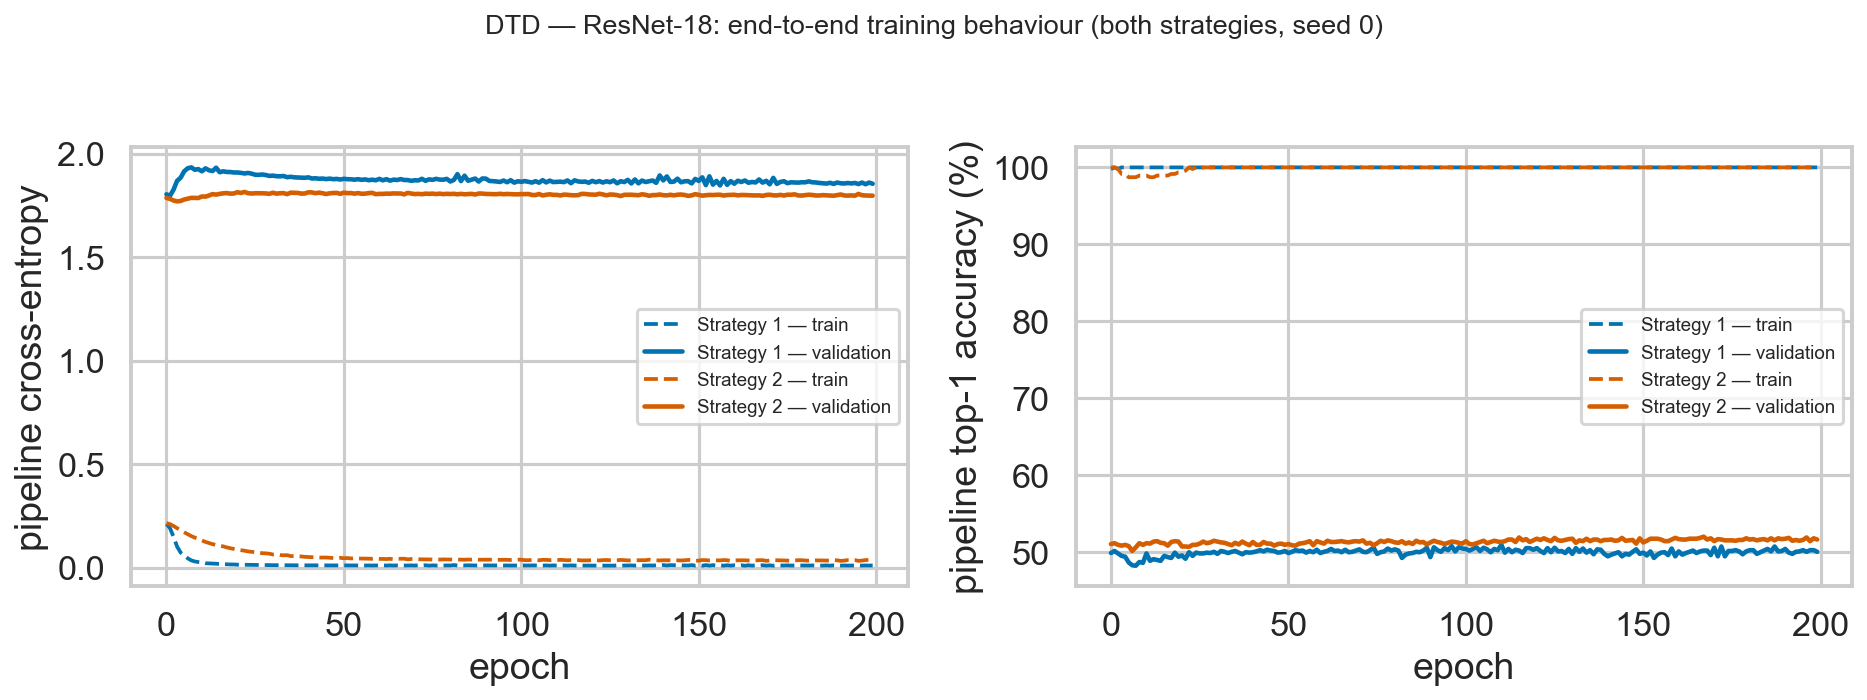

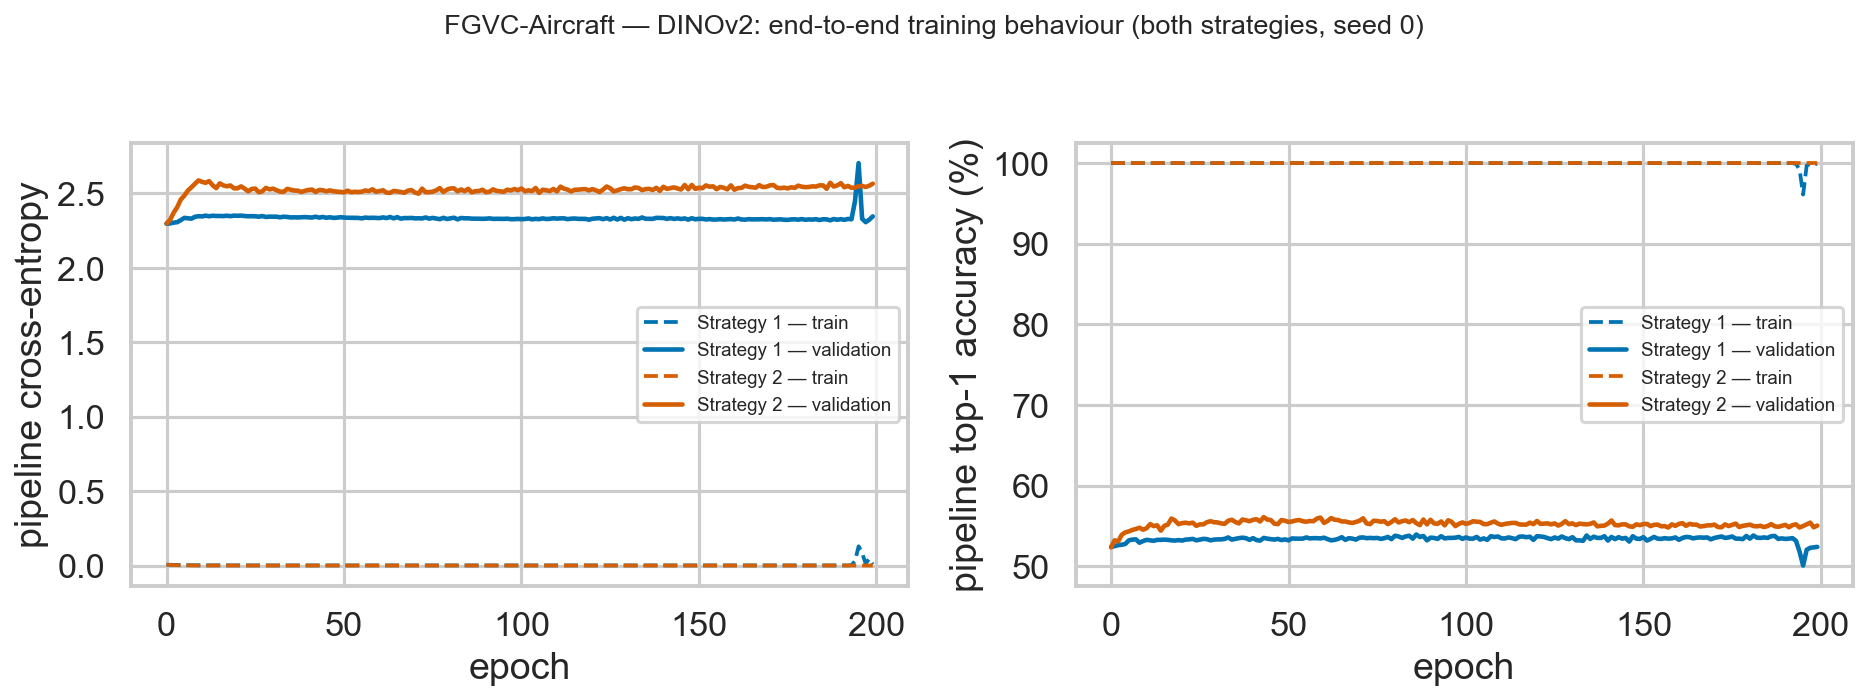

In [14]:
for ds, enc in cfg["stage3"]["settings"]:
    display(Image(str(FIG / f"stage3_curves_{ds}_{enc}.png"), width=980))

**Strategy-internal diagnostics — separate axes, deliberately.** These quantities measure different things and are never drawn on a shared axis: Strategy 1's relative displacement penalty; Strategy 2's FM-regression loss; Strategy 2's target construction (CE of the unprojected snapshot output — diagnostic only; CE at the projected $u_0$; CE at the selected target) with the **trust-region hit rate** (fraction of samples whose target sits on the boundary $\lVert\hat{z}' - z\rVert = \rho$) on the twin axis; and the mean displacements. Note the S2 phase-1 values describe the *pre-update* snapshot of each epoch, while its validation values describe the post-update model — a one-phase offset inherent to the two-phase scheme.

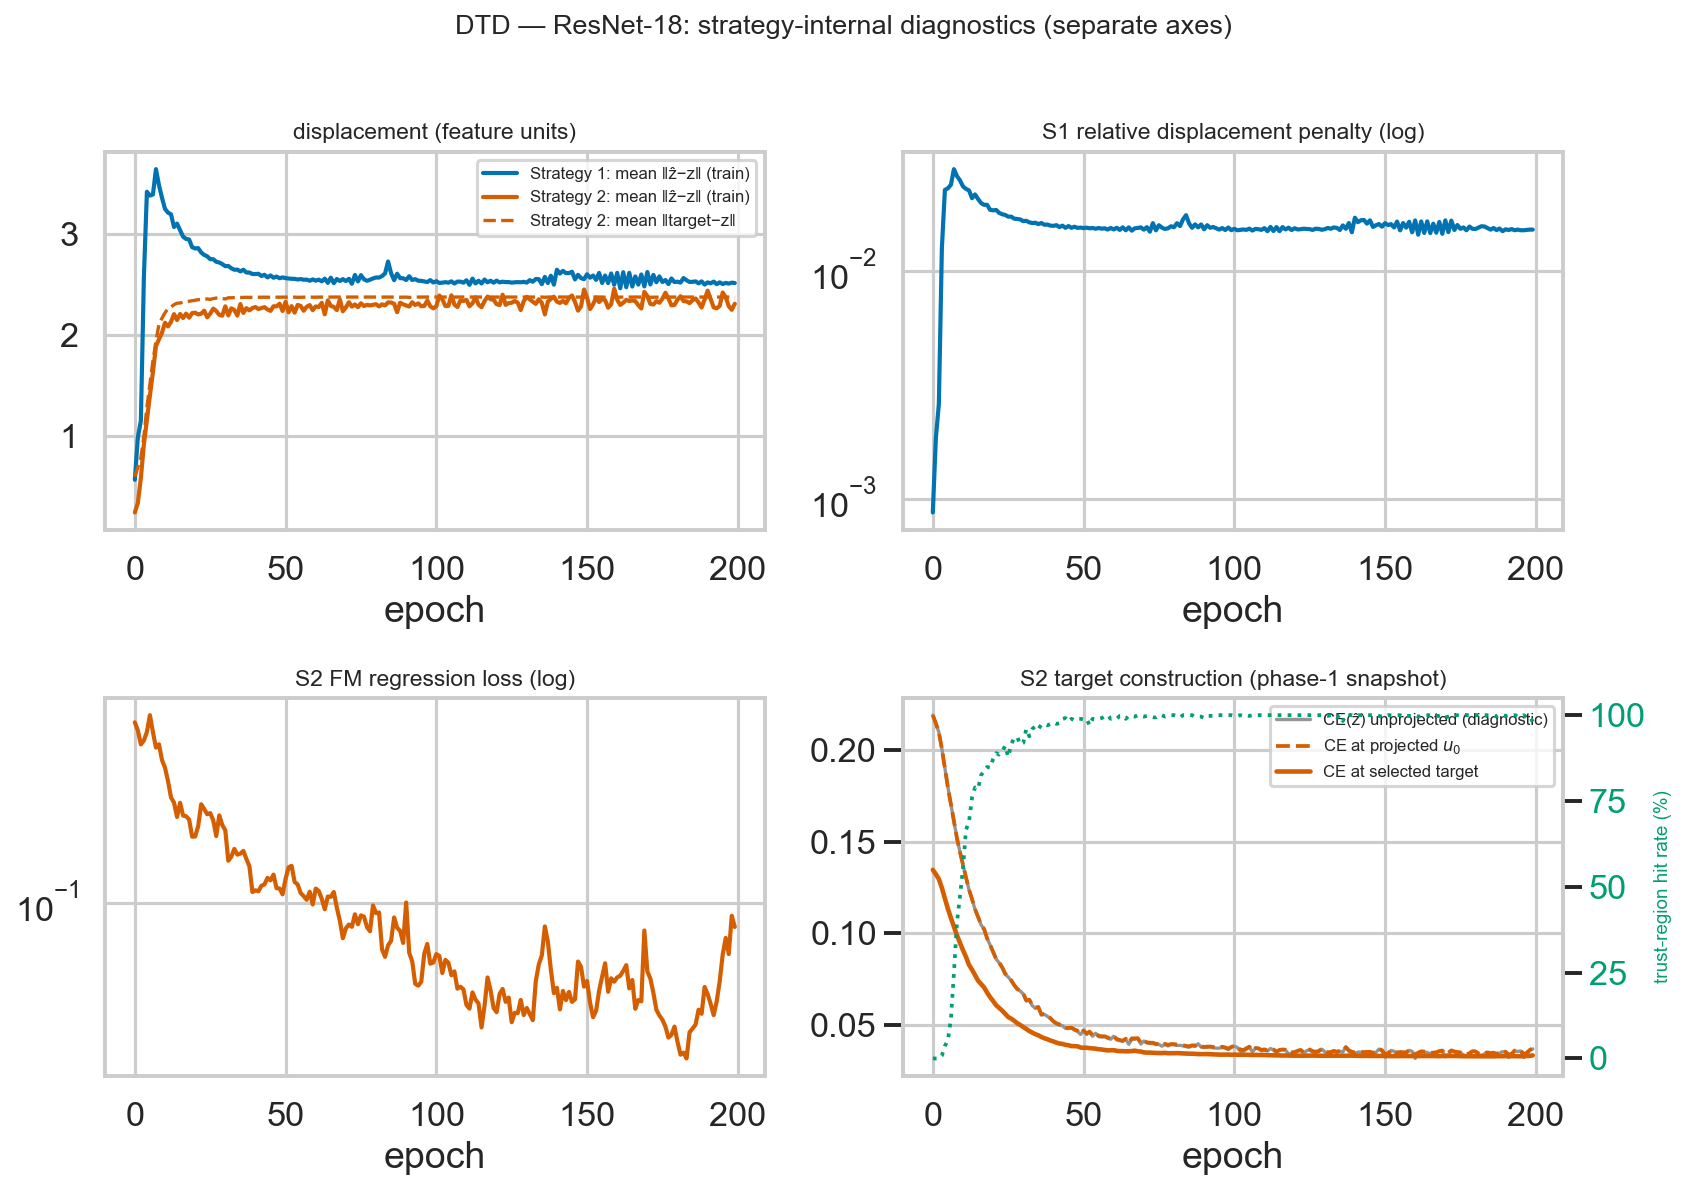

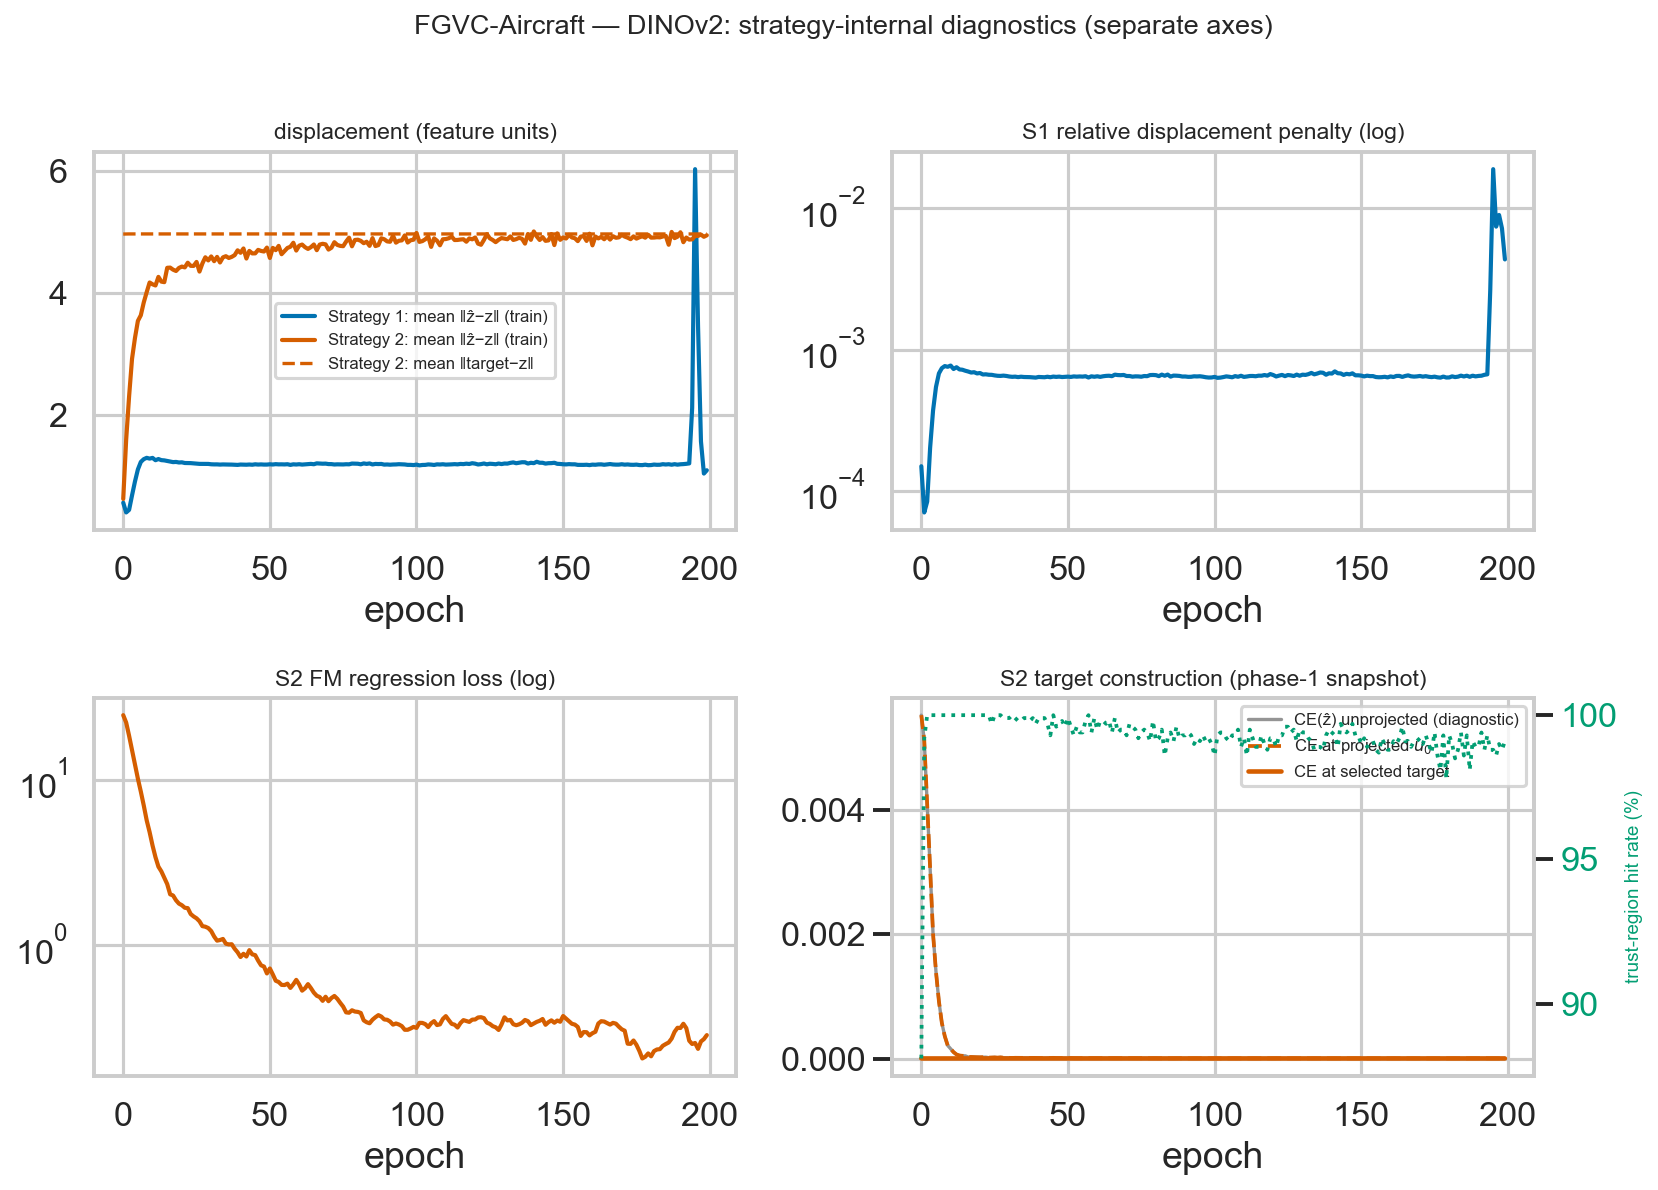

In [15]:
for ds, enc in cfg["stage3"]["settings"]:
    display(Image(str(FIG / f"stage3_diag_{ds}_{enc}.png"), width=1150))

**Feature-space figures of record** (Sections 9–10 re-render the same selection, models and joint PCA with larger fonts; the explained-variance labels are asserted to match these):

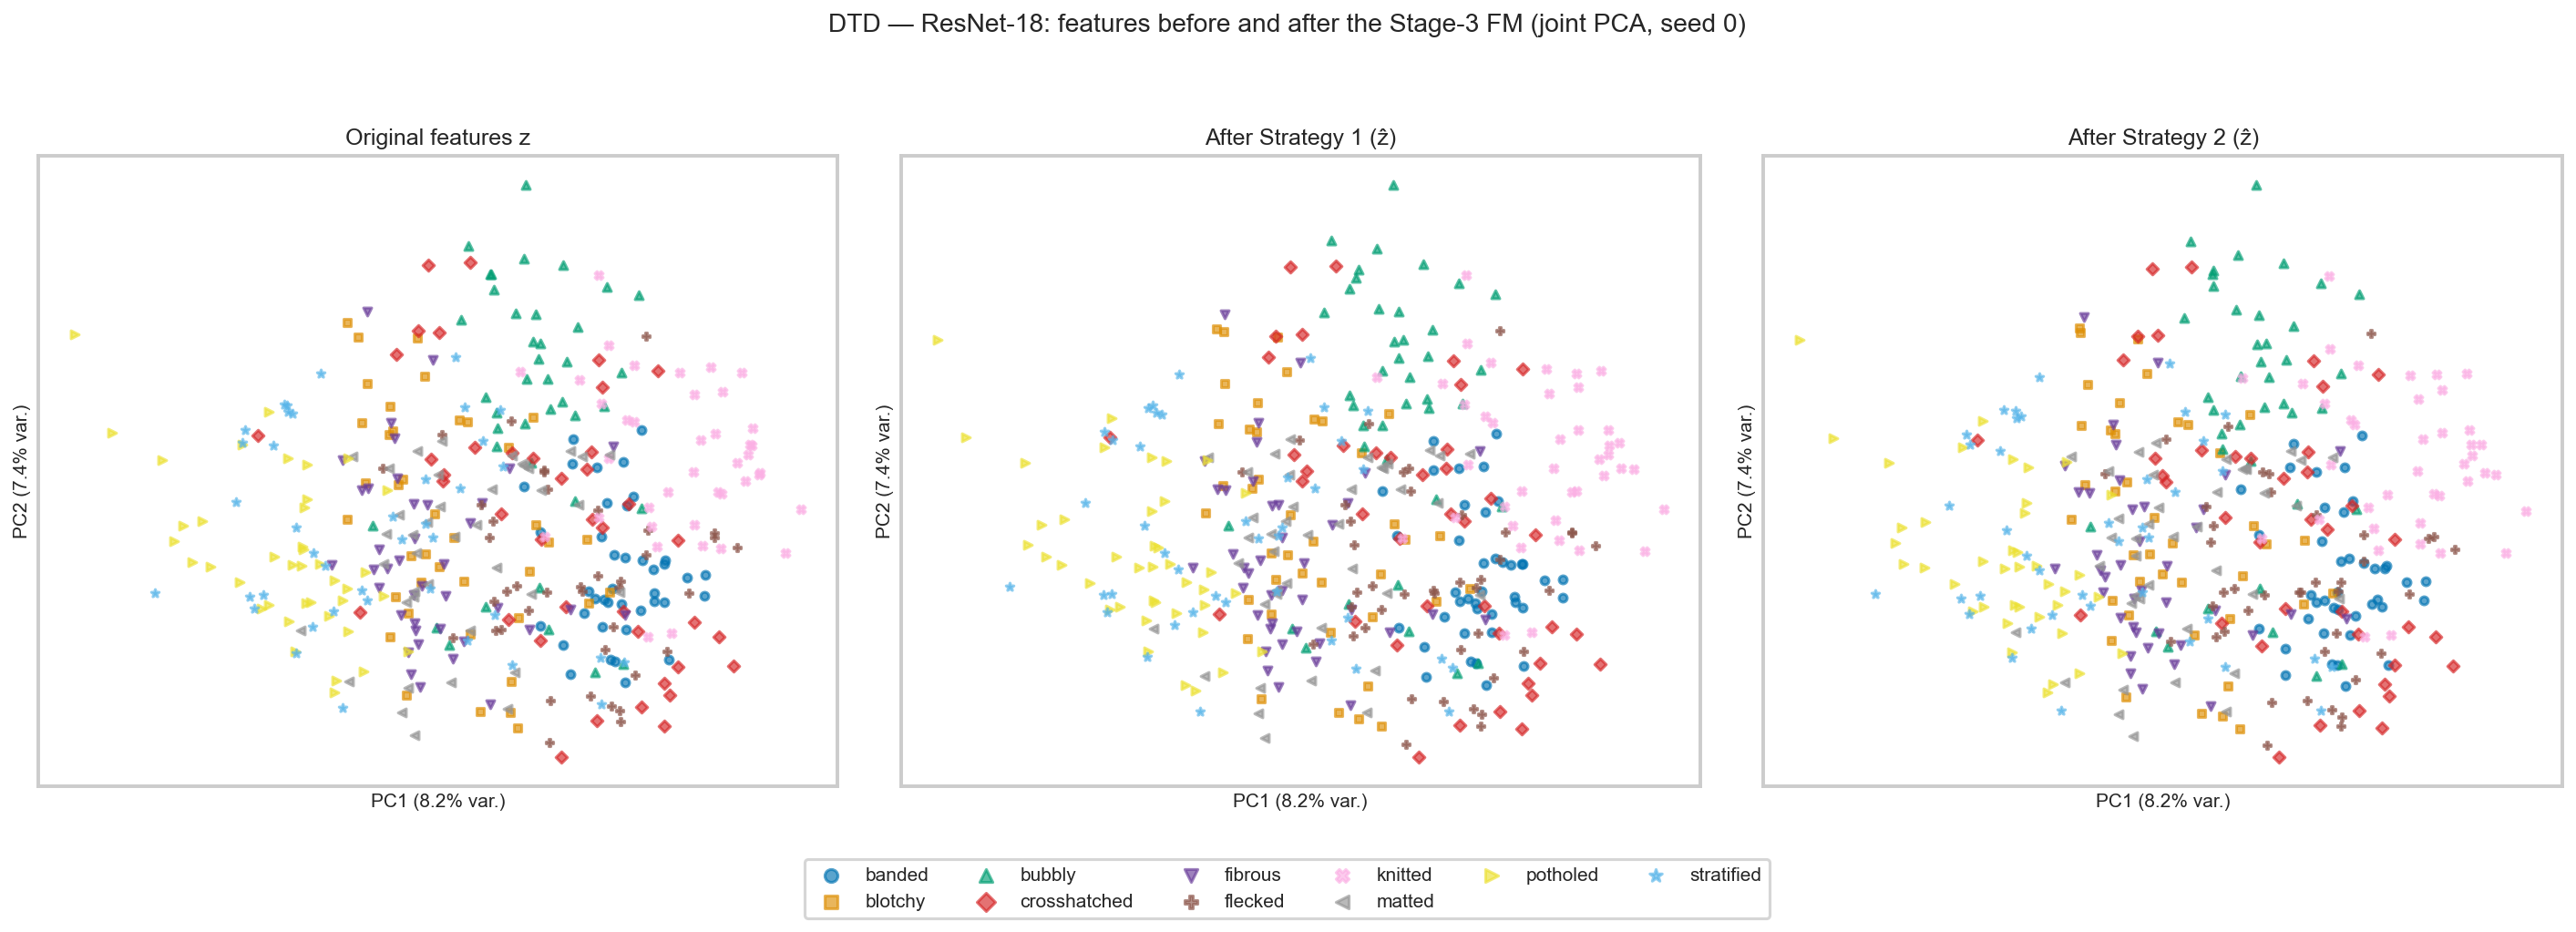

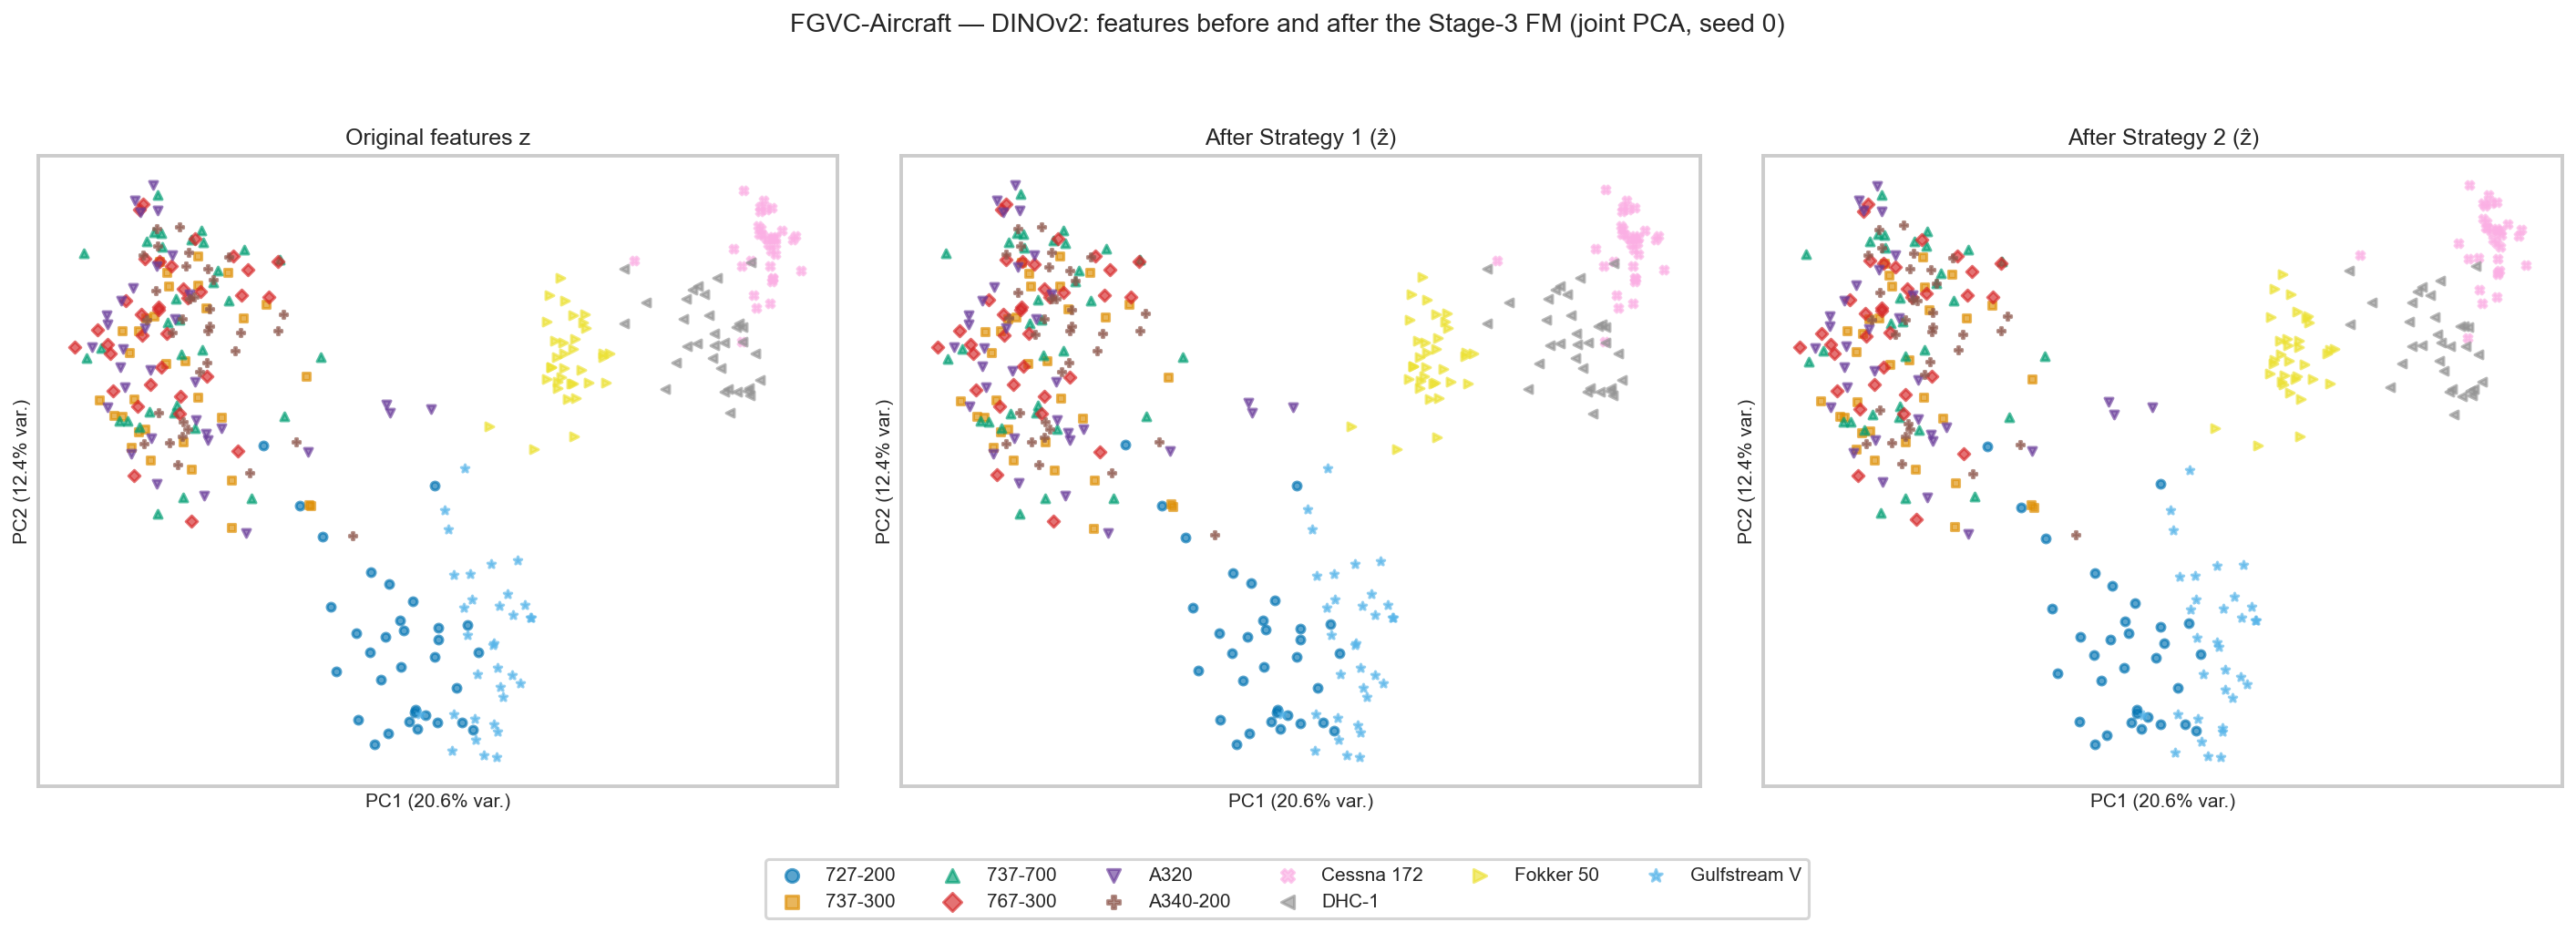

In [16]:
for ds, enc in cfg["stage3"]["settings"]:
    display(Image(str(FIG / f"stage3_features_{ds}_{enc}.png"), width=1150))

## <span style="color:#1f3a5f;">A.9 · Checkpoint placement and displacement</span>

In [17]:
# Checkpoint epoch from the table of record (runs_stage3.csv), which applies the
# full tie-break rule (validation accuracy -> validation CE -> earliest epoch).
HEADS = {"fm_s1": "Strategy 1", "fm_s2": "Strategy 2"}
r3 = pd.read_csv(MET / "runs_stage3.csv")
rows = []
for ds, enc in cfg["stage3"]["settings"]:
    for head in ("fm_s1", "fm_s2"):
        for seed in cfg["stage3"]["subset_seeds"]:
            with open(CURVES / f"{ds}_{enc}_{head}_seed{seed}.json") as f:
                h = json.load(f)
            ep = int(r3[(r3["dataset"] == ds) & (r3["encoder"] == enc)
                        & (r3["head"] == head)
                        & (r3["seed"] == seed)]["checkpoint_epoch"].iloc[0])
            rows.append({"dataset": dataset_label(ds), "strategy": HEADS[head],
                         "seed": seed,
                         "best val acc (%)": round(100 * max(h["val_acc"]), 2),
                         "checkpoint epoch": ep,
                         "‖ẑ−z‖ at checkpoint": round(h["mean_disp"][ep], 3)})
print("Checkpoint placement and displacement — the two mandatory strategies' "
      "final models (λ=0 and the optional-extension models are tabulated in "
      "A.6 / A.10):")
display(pd.DataFrame(rows))
failed = sorted(CURVES.glob("*_failed_lv*.json"))
print(f"Failed training attempts (partial curves saved): {len(failed)}"
      + (" — " + ", ".join(p.name for p in failed) if failed else
         " — no NaN/Inf occurred; every run completed at fallback level 0 "
         "(the default recipe)."))

Checkpoint placement and displacement — the two mandatory strategies' final models (λ=0 and the optional-extension models are tabulated in A.6 / A.10):


,dataset,strategy,seed,best val acc (%),checkpoint epoch,‖ẑ−z‖ at checkpoint
0,DTD,Strategy 1,0,50.90,110,2.54
1,DTD,Strategy 1,1,54.57,79,2.55
2,DTD,Strategy 1,2,51.22,179,3.15
3,DTD,Strategy 2,0,51.97,167,2.29
4,DTD,Strategy 2,1,55.21,185,2.34
5,DTD,Strategy 2,2,52.82,175,2.28
6,FGVC-Aircraft,Strategy 1,0,53.95,86,1.19
7,FGVC-Aircraft,Strategy 1,1,52.45,117,1.14
8,FGVC-Aircraft,Strategy 1,2,50.29,36,1.24
9,FGVC-Aircraft,Strategy 2,0,56.11,43,4.69


Failed training attempts (partial curves saved): 0 — no NaN/Inf occurred; every run completed at fallback level 0 (the default recipe).


## <span style="color:#1f3a5f;">A.10 · Optional joint-training experiment</span>

Run only after the mandatory comparison was complete (ADR 0008 §9): joint FM + classifier fine-tuning (classifier lr 1e-4, FM lr 1e-3, same policy), against the **classifier-only continued-training control** — the pinned probe trained further *alone* with the same budget.

In [18]:
display(Markdown((MET / "stage3_joint_table.md").read_text(encoding="utf-8")))

| Dataset / encoder | Variant | Top-1 (%) | Δ vs pinned probe (pts) |
|---|---|---|---|
| DTD / ResNet-18 | Joint FM + classifier fine-tuning | 53.88 ± 0.63 | -0.43 ± 0.37 |
| DTD / ResNet-18 | Control: classifier-only continued training | 54.26 ± 0.46 | -0.05 ± 0.19 |
| DTD / ResNet-18 | (reference) Strategy 2, frozen classifier | 54.47 ± 0.70 | +0.16 ± 0.45 |
| FGVC-Aircraft / DINOv2 | Joint FM + classifier fine-tuning | 51.86 ± 0.96 | +0.56 ± 0.98 |
| FGVC-Aircraft / DINOv2 | Control: classifier-only continued training | 51.94 ± 0.98 | +0.64 ± 0.08 |
| FGVC-Aircraft / DINOv2 | (reference) Strategy 2, frozen classifier | 53.80 ± 0.95 | +2.50 ± 0.50 |

Optional extension (ADR 0008 §9), run after the mandatory comparison: the classifier is unfrozen (lr 1e-4; FM lr 1e-3; same policy, 3 seeds). The **control** trains the pinned classifier further *alone* with the same budget — without it, a joint gain could not be attributed to the FM rather than to the classifier simply training longer. Same pinned-probe baselines as the main table.

## <span style="color:#1f3a5f;">A.11 · Classifier-only continued-training control</span>

**The control earns its place — and inverts the expected story.** The joint variant was pre-registered as an "upper reference"; it is not one. The joint variant does not outperform classifier-only continued training in these three seeds (FGVC: +0.56 ± 0.98 vs +0.64 ± 0.08; per-seed joint − control: +0.06 / −1.08 / +0.78; DTD: both ≈0/slightly negative), so **the results provide no evidence of an additional FM-attributable gain when the classifier is unfrozen**. The early validation-selected checkpoints (epochs 0–18, single-digit in 5 of 6 runs) are consistent with rapid overfitting in the K = 10 regime, but this experiment does not isolate classifier freezing as the cause — particularly because the best frozen configuration uses Strategy 2 while joint training uses a different objective. Even the closest matched-objective comparison (frozen Strategy 1 vs joint, both CE-trained) does not separate the two (+0.88 ± 0.23 vs +0.56 ± 0.98). **Empirically, frozen-classifier Strategy 2 remains the best tested configuration.** (Without the control, the +0.56 could have looked like a small FM win — exactly the confound the external review flagged.)

## <span style="color:#1f3a5f;">A.12 · Full limitations</span>

- **$n = 3$ subset seeds**; spreads are sample standard deviations; no significance claims. The spread measures subset-sampling variability only (probe-init and FM-init are fixed).
- **Seed 0 is partly a development run** — hyperparameters were selected on its validation split; the 3-seed mean is a summary, not an independent confirmatory estimate (pre-registered disclosure).
- **One K, one T, one encoder per dataset** — by the spec's own scoping ("to keep this stage focused"); conclusions are about this operating point.
- **The λ-ablation pair can degenerate**: where λ = 0 wins the sweep, the with/without-regularization contrast is absent from the test table by construction (stated in ADR 0008 §7).
- **2-D projections are qualitative**; the joint-PCA plane explains 15.6% (DTD) / 33.0% (FGVC) of the variance only.
- **The Strategy-2 trust region was active for nearly all targets after the early epochs** (hit rate ≈100%, A.8 diagnostics). Consequently, performance may depend materially on the fixed choice α = 0.1; no α ablation was performed (future work, or a clearly-labelled validation-only exploration).
- Although the linear classifier is frozen, **the FM adds nonlinear capacity** by warping feature space — $W F_\theta(z) + b$ can represent nonlinear decision boundaries even with $W, b$ fixed. The conclusions are therefore limited to the chosen FM architecture, K = 10, T = 4, and the fixed trust-region radius — not to "what a frozen classifier can do" in general.

## <span style="color:#1f3a5f;">A.13 · Deviations from, and extensions beyond, the specification</span>

| Item | Status | Note |
|---|---|---|
| Probe trained first exactly as Stage 1, then frozen | as specified | retrained per (dataset, seed) with the Stage-1 recipe; validation audit vs `runs.csv`: 0.000 pts and exact best-epoch match on all six probes; weights pinned |
| FM close to identity | as specified (strengthened) | zero final layer ⇒ **exact** identity, asserted at feature/logit/prediction level (A.2) |
| Velocity net + Euler as Stage 2; single T; K = 10 | as specified | T = 4 pre-registered (shallower backprop for Strategy 1); K = the spec's suggested default |
| Both strategies + main comparison + deliverables | as specified | table + Δ; train/val curves both methods; joint-embedding feature viz |
| Relative displacement penalty (S1); trust region, monotone acceptance, per-epoch cached targets (S2) | within spec freedom | the spec explicitly invites regularization (S1) and constrained target updates (S2); all details pre-registered in ADR 0008 |
| Validation-accuracy checkpointing | our choice (spec silent) | symmetric to how the baseline probe itself was selected; identical rule for both strategies |
| Repetition protocol (3 subset seeds) | our choice (spec silent) | keeps paired Δ ± std, consistent with Stages 1–2 |
| Optional joint fine-tuning extension + classifier-only control | done (A.10–A.11) | run after the mandatory comparison, exactly per ADR 0008 §9; the control shows the joint gain is fully explained by longer classifier training |

## <span style="color:#1f3a5f;">A.14 · Artifact paths and reproduction commands</span>

| Artifact | Path |
|---|---|
| Per-run and summary results | `results/metrics/runs_stage3.csv`, `summary_stage3.csv`, `raw/stage3_*.npy` |
| Selection transparency | `results/metrics/stage3_sweep.csv` (+ generated `stage3_*_table.md`) |
| Training histories (every model, incl. failed attempts) | `results/artifacts/curves_stage3/*.json` |
| Pinned probes + trained FM models | `results/artifacts/stage3_models/*.pt` (gitignored, regenerable via `tasks.ps1 run3`) |
| Run-0 predictions | `results/artifacts/predictions/run3_*.npz` |
| Figures | `results/figures/stage3_*.png` |

Reproduce with `tasks.ps1 run3 / tables3 / figures3 / notebook3`; `tasks.ps1 check` re-derives every summary number, every paired Δ (against the stored pinned-probe baselines), and every generated table from raw artifacts.

**Provenance.** This notebook re-executes only inside its repository (`alonengel/Computer-Vision-Project`, private — available on request); as a standalone file it is fully readable (all outputs embedded) but not re-runnable — the repo, not the notebook, is the unit of reproduction.

**How this presentation notebook was built.** Assembled from `notebooks/nb3_talk_v2_sections/s*.py` by `notebooks/build_talk_notebook.py v2` and executed with `jupyter nbconvert --execute`; it reads only `results/` (tables, histories and figures of record) and the pinned models, and writes nothing back. The scientific notebook `stage3_presentation.ipynb`, its sections, the source code and every artifact are unchanged.